## Tutorial: Analyze color and spectral indices with PlantCV-Geospatial

This tutorial uses PlantCV-Geospatial v1.0. Last updated August 12, 2026. You must have PlantCV and PlantCV-Geospatial installed to use this tutorial. For installation instructions, visit [this page for PlantCV](https://docs.plantcv.org/en/stable/installation/) and [this page for PlantCV Geospatial](https://docs.plantcv.org/projects/geospatial/en/latest/installation/). 

Data used in this tutorial is from the following publication: 

    Brown, K. E., Schuhl, H., Srivastava, D., Beyene, G., Li, M., Fahlgren, N., & Murphy, K. M. (2026). Quantifying growth and lodging in Tef (Eragrostis tef) with Uncrewed Aerial Systems (UAS). Plant Direct, 10(5), e70173.
  


This tutorial is an example workflow for analyzing color and spectral indices for regions in a geojson shapefile.. This will cover basics of:
  - Reading in images with `plantcv-geospatial` (`gcv`)
  - Using the `field_layout` class in `gcv`
  - Image classes in `gcv`
  - Using the `InteractiveShapes` class to create a field boundary shapefile
  - Analysis of color
  - Analysis of spectral indices

## Step 1: Load in packages and specify parameters

First, we load `plantcv.geospatial`. Here we also load the main `plantcv.plantcv.` package so that we can set our debug parameter and for checking our `outputs` class later.

In [2]:
from plantcv import geospatial as gcv
from plantcv import plantcv as pcv
pcv.params.debug = "plot"

Those familiar with `PlantCV` may be used to interacting with `pcv.params` to control debug behavior, text thickness, and other such variables that are used in many functions.

In `gcv` we add a similar [singleton class called `field_layout`](https://docs.plantcv.org/projects/geospatial/en/latest/Field_layout/) which you can use to keep several useful metrics about your particular field data. See the linked docs for a full list of attributes and for where they are used.

![Field Layout Terminology](img/row_plot_vocab.png)

In [3]:
#Using the field layout of the data we are analyzing, we will specify the number of ranges, columns, and the spacing between them, as well as the range length and row length. 

gcv.field_layout.num_ranges = 3
gcv.field_layout.num_columns = 3
gcv.field_layout.range_spacing = 1.4
gcv.field_layout.range_length = 3.5
gcv.field_layout.row_length = 4.5
gcv.field_layout.column_spacing = 1.3

## Step 2: Import (aka read) in an image. 
With our parameters set we are ready to read in an image.

`gcv.read` currently supports `.geotif` and select `.netcdf` files (as more accepted standards come out of the netcdf format we may expand to include more supported types there).

`gcv.read.geotif` is used here to read in a grayscale `.tif` file. There are four arguments to `read.geotif`:
- 1: 'filename': The path to a file
- 2: 'bands': Bands to read, defaults to "R,G,B" but supports R, G, B, RE, N, NIR, and GRAY.
- 3: 'cropto': Defaults to None but can be a path to a shapefile to crop the image to.
- 4: 'cutoff': Defaults to None but can be a percentile above which to remove points in grayscale images.


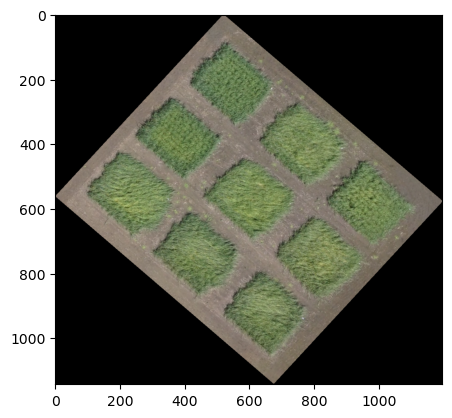

In [4]:
#Here, we will import a small RGB test image of 9 plots of Teff.  

img = gcv.read.geotif("./small_teff_example.tif", bands="r,g,b")

To keep track of important metadata when handling these images `gcv` includes two image classes, `GEO` and `DSM`.

`GEO` objects hold any multi-channel geospatial images and are a subclass of `numpy.ndarray` with special methods/attributes for a thumbnail (`thumb`), coordinate reference system (`crs`), transformations (`transfrom`), nodata values (`nodata`), wavelengths (`wavelengths`, which are numerical wavelength values found in the image metadata), and default wavelengths (`default_wavelengths`, which are a lookup table of defaults if a user inputs band names, such as NIR), and retrieving array slices from a wavelength (`get_wavelength(wavelength)`) as another `GEO` object.

`DSM` or "**D**igital **S**urface **M**odel" objects are essentially the same thing but as a grayscale image, which is a useful differentiation for the `gcv` internals.

Here we will work with a `GEO` object because we need all available color channels for analysis.

In [4]:
#If you want to check the type of the imported image, you can use the following command:

type(img)

plantcv.geospatial.images.GEO

## Step 3: Annotate field coordinates

The next feature of `gcv` that we'll look at is the `InteractiveShapes` class. This class works with a `napari` viewer to allow for annotation of important field coordinates.

This next cell opens a Napari window, where you can create layers. The call to `InteractiveShapes` will default to making a polygon layer called `field_boundary`, which is useful for several kinds of plot boundary creation methods. However, we are going to use a method that requires a points-type shapefile instead. Immediately after creating the napari editor, the next cell will add a `Points` layer. Click on that layer in the bottom left of the napari window and then add clicked points to the 4 corners of the whole field, progressing clock-wise from the top left corner. 

**Important!** For automated plot boundary creation with `autogrid`, it is necessary to keep your clicks as close to the plot corners as possible. 

The `InteractiveShapes` class has a `close()` method, but keep the viewer open for now to see what other functions do with it.

In [5]:
# Open the Napari viewer to interactively draw the field boundary. 

editor = gcv.create_shapes.InteractiveShapes(
    img=img,
    viewer_type="napari",
    field_layer="field_boundary",
    show=True
    )

editor.add_layer(layer_type="points", layername="field_corners")

The `InteractiveShapes` class has several helpful methods, the first of which is `to_points`. This lets us save a points layer to a geojson file.

In [6]:
#Save the field_corners layer as a geojson file, then close the viewer. 

corners = editor.to_points(dest="field_corners.geojson", layername="field_corners")

editor.close()

## Step 4: Automatically define plots in the field. 

Next, since we defined traits of our field in the `field_layout` class we can call `auto_grid` to automatically cut our field into plots.
If you have a less perfect rectangle then you may need to use [other methods](https://docs.plantcv.org/projects/geospatial/en/latest/shapes_grid_from_coords/) to label your plots.

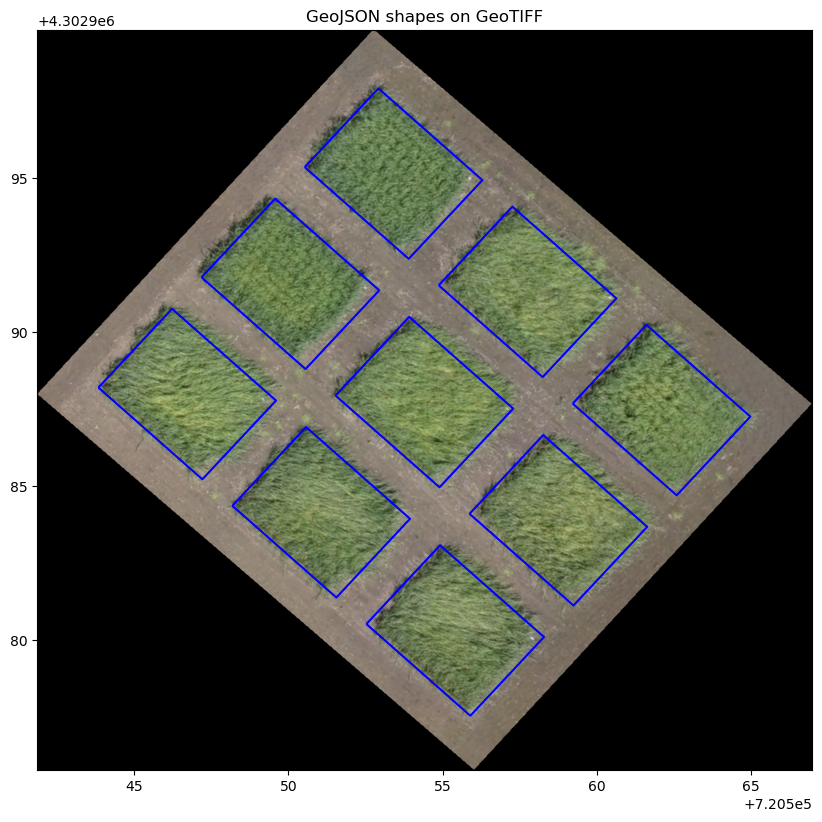

In [9]:
# Auto_grid will save plot boundaries to a new shapefile called plots.geojson

plotsfig = gcv.create_shapes.auto_grid(img, "./field_corners.geojson", "./plots.geojson")

If the plots look off, change your parameters in the `field_layout` class until you are happy with them. 


## Step 5: Segment plants.

Because we only want to know the color of the plant material and not any soil that is also within our plot boundaries, we will use a threshold to perform segmentation. The following steps use main PlantCV functions, and more information can be found in the various segmentation tutorials on the [PlantCV website](https://plantcv.org/tutorials).

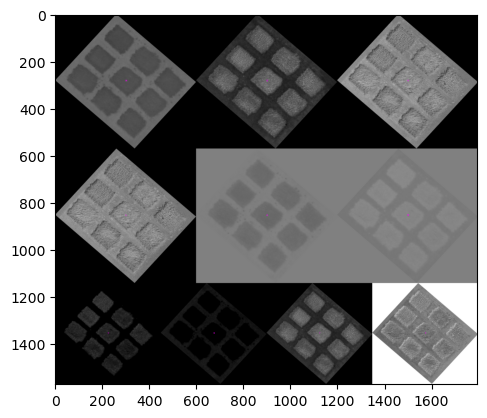

In [6]:
# First, visualize the image in grayscale color spaces to determine which separates plants from soil best

vis = pcv.visualize.colorspaces(img, original_img=False)

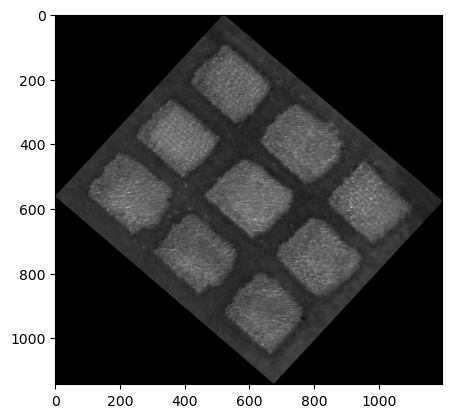

alt.Chart(...)

In [5]:
# Channel s from the HSV colorspace looks good
# Let's convert the image to grayscale in that channel and look at the distribution of pixel values

gray_s = pcv.rgb2gray_hsv(img, channel="s")

dist = pcv.visualize.histogram(gray_s)

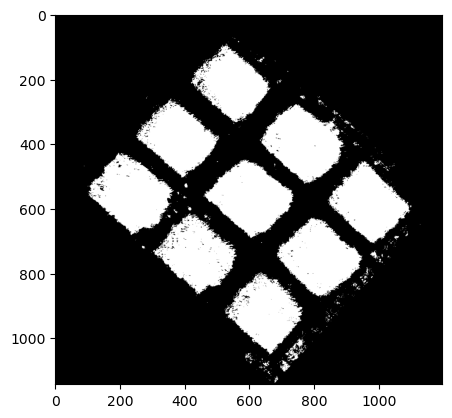

In [6]:
# Using the histogram as a guide, choose a threshold that captures your plots
# Threshold your grayscale image to create a binary plant mask

binmask = pcv.threshold.binary(gray_s, threshold=60, object_type="light")

Though the mask contains some pixels outside of our plant plot, we will not worry about cleaning it up since we constrain color analysis to our plot boundaries anyway. 

## Step 6: Analyze color. 

Now we are ready to analyze color. 

The color analysis function takes the input image, the binary plant mask, the geojson shape file containing plot boundaries that we made with `auto_grid`, the number of bins to put color values into to report the distribution, and which colorspaces you would like information for. There is also an option `label` parameter that is useful if you are including multiple time points in one analysis. 

In [18]:
# Analyze color within each plot boundary

color = gcv.analyze.color(img, binmask, geojson="plots.geojson", bins=10, colorspaces="hsv", label=None)

alt.Chart(...)

The debug image shown is the distribution of hue circular mean values across our plots. We only have 9, so the distribution is not very informative, but if you had 100's or 1000's of plots, this would give you some information about overall color in your whole field at a glance. 

In [19]:
#To see the results of the analysis, you can use the following command to view the observations in the output file.

pcv.outputs.observations["default_1"]

{'hue_circular_mean': {'trait': 'hue circular mean',
  'method': 'plantcv-geospatial.analyze.color',
  'scale': 'degrees',
  'datatype': "<class 'float'>",
  'value': 95.05198669433594,
  'label': 'degrees'},
 'hue_circular_std': {'trait': 'hue circular standard deviation',
  'method': 'plantcv-geospatial.analyze.color',
  'scale': 'degrees',
  'datatype': "<class 'float'>",
  'value': 5.416749954223633,
  'label': 'degrees'},
 'hue_frequencies': {'trait': 'hue frequencies',
  'method': 'plantcv-geospatial.analyze.color',
  'scale': 'frequency',
  'datatype': "<class 'list'>",
  'value': [72, 28856, 4448, 0, 0, 0, 0, 0, 0, 0],
  'label': [0.0,
   25.5,
   51.0,
   76.5,
   102.0,
   127.5,
   153.0,
   178.5,
   204.0,
   229.5,
   255.0]},
 'hue_mean': {'trait': 'hue mean',
  'method': 'plantcv-geospatial.analyze.color',
  'scale': 'none',
  'datatype': "<class 'float'>",
  'value': 47.52793314255983,
  'label': 'none'},
 'hue_std': {'trait': 'hue standard deviation',
  'method': 'pla

## Step 7: Analyze spectral indices. 

In addition to information about color, you might be interested in spectral indices, which are calculated from available wavelengths. To find a full list and explanation of all the indices available, see the [PlantCV documentation](https://docs.plantcv.org/en/stable/spectral_index/). Because we only have RGB channels in the current image, we will use an index that does not require additional bands, the red-green ratio index (RGRI). 

PlantCV-Geospatial uses main PlantCV's functions to analyze spectral indices, so you can specify any index available in PlantCV. Additionally, the function requires a geojson and can optionally take a binary mask. You can also set any percentiles you would like calculated for your index per plot, an optional label, and a distance to the target wavelength in case your orthomosaic has variable wavelengths for each band.  

/Users/kbrown/miniforge3/envs/plantcv/lib/python3.12/site-packages/plantcv/plantcv/transform/rescale.py:30: RuntimeWarning: invalid value encountered in cast
  rescaled_img = (rescaled_img).astype('uint8')


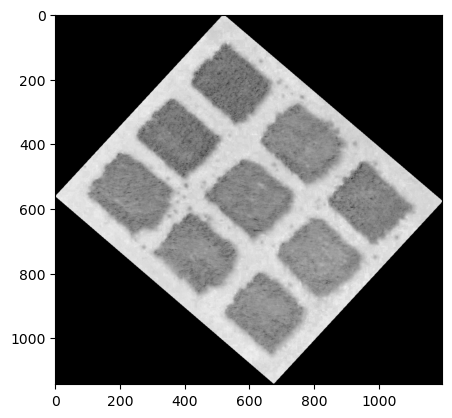

/Users/kbrown/miniforge3/envs/plantcv/lib/python3.12/site-packages/rasterstats/io.py:335: NodataWarning: Setting nodata to -999; specify nodata explicitly
  warnings.warn(


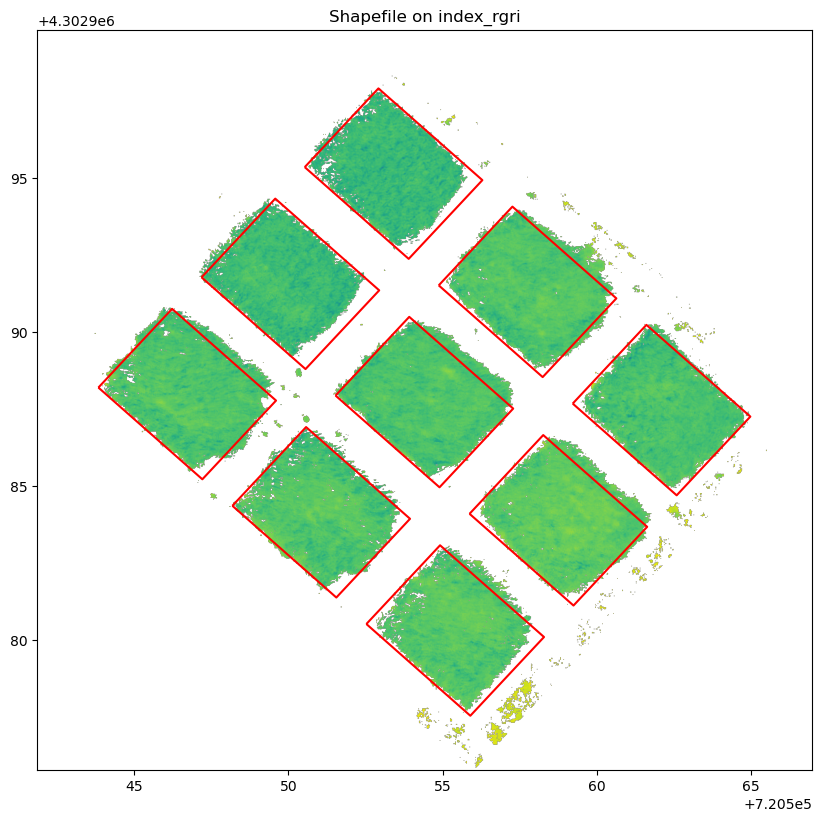

In [10]:
spec = gcv.analyze.spectral_index(img, geojson="./plots.geojson", index="rgri", mask=binmask)

## Step 6: Save the results. 
We can save the results per standard `pcv.outputs` behavior once our analysis is complete.

In [11]:
# Save the results of the analysis to a JSON file named "res.json". 

pcv.outputs.save_results("results.json")

We hope that this is a useful getting started guide for color and spectral index analysis in `PlantCV-Geospatial`.

For details about functions please see the [online documentation](https://docs.plantcv.org/projects/geospatial/en/latest/).

For questions about the docs, bug reports, feature requests, and other issues please open a [github issue](https://github.com/danforthcenter/plantcv-geospatial/issues) and our team will try to help!